# Метод опорных векторов

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_circles
from sklearn.svm import SVC
from sklearn import metrics

In [2]:
def plot_decision_regions(X, y, model):
    plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], 
                linewidth=7, facecolors='green', label='support vectors')

    plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100, label='class 0')
    plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100, label='class 1')

    X0 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
    X1 = np.linspace(X[:, 1].min(), X[:, 1].max(), 100)
    X0_grid, X1_grid = np.meshgrid(X0, X1)
    Z = model.decision_function(np.array([X0_grid.ravel(), X1_grid.ravel()]).T).reshape(X0_grid.shape)
    plt.contour(X0_grid, X1_grid, Z, colors='k', levels=[-1, 0, 1], linestyles=['--', '-', '--'])
    plt.contourf(X0_grid, X1_grid, Z, levels=[-1, 0, 1], alpha=0.2, colors='grey')
    plt.xlabel('X0')
    plt.ylabel('X1')
    plt.legend()
    plt.show()

In [3]:
X, y = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.4)

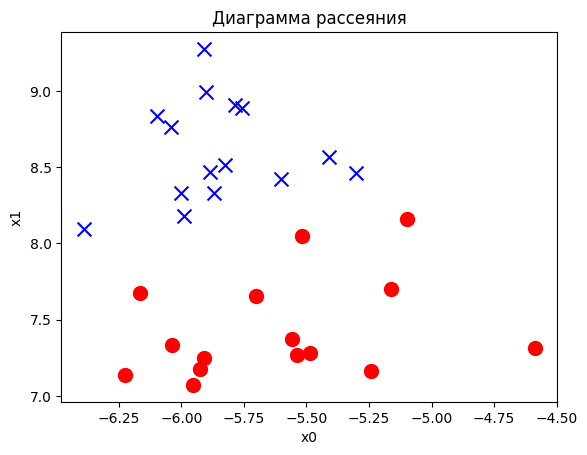

In [4]:
plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния")
plt.xlabel('x0')
plt.ylabel('x1')
plt.show()

In [5]:
svm_linear = SVC(kernel='linear', C=100)
svm_linear.fit(X, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [6]:
svm_linear.coef_

array([[-2.49920793,  6.14683189]])

In [7]:
svm_linear.intercept_

array([-64.2533988])

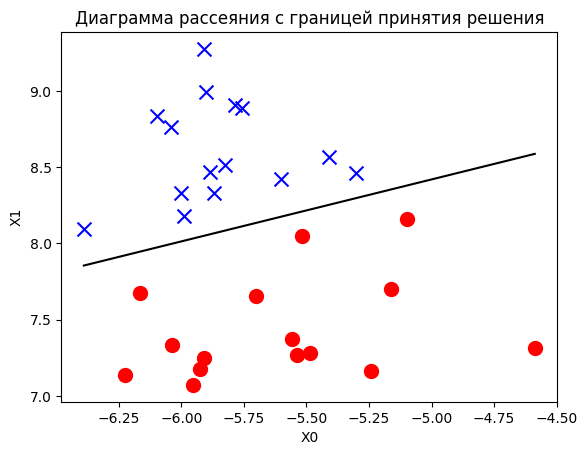

In [8]:
X0 = np.linspace(X[:, 0].min(),X[:, 0].max(), X.shape[0])

plt.plot(X0,-svm_linear.intercept_[0]/svm_linear.coef_[0][1]-svm_linear.coef_[0][0]/svm_linear.coef_[0][1]*X0, c='k')

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния c границей принятия решения")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

In [9]:
svm_linear.support_vectors_

array([[-5.51629264,  8.04763857],
       [-5.30025769,  8.46071981],
       [-5.9879581 ,  8.18112559]])

In [10]:
svm_linear.support_

array([ 0,  8, 29], dtype=int32)

In [11]:
svm_linear.n_support_

array([1, 2], dtype=int32)

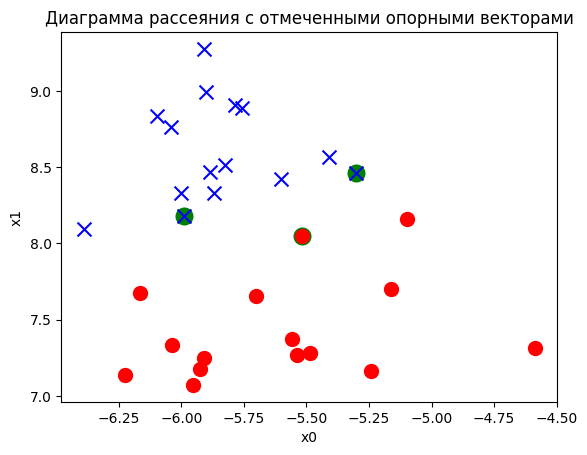

In [12]:
plt.scatter(svm_linear.support_vectors_[:, 0],svm_linear.support_vectors_[:, 1], linewidth=7, facecolors='green')

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния c отмеченными опорными векторами")
plt.xlabel('x0')
plt.ylabel('x1')
plt.show()

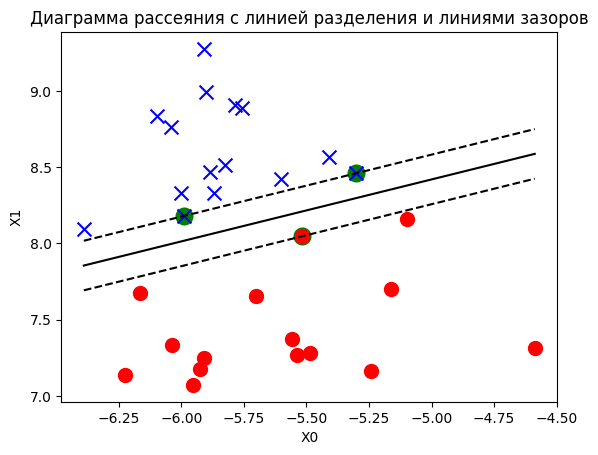

In [13]:
plt.plot(X0,-svm_linear.intercept_[0]/svm_linear.coef_[0][1]-svm_linear.coef_[0][0]/svm_linear.coef_[0][1]*X0, c='k')

plt.plot(X0,(-svm_linear.intercept_[0]-1)/svm_linear.coef_[0][1]-svm_linear.coef_[0][0]/svm_linear.coef_[0][1]*X0,linestyle='--', c='k')
plt.plot(X0,(-svm_linear.intercept_[0]+1)/svm_linear.coef_[0][1]-svm_linear.coef_[0][0]/svm_linear.coef_[0][1]*X0,linestyle='--', c='k')

plt.scatter(svm_linear.support_vectors_[:, 0],svm_linear.support_vectors_[:, 1], linewidth=7, facecolors='green')

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния c линией разделения и линиями зазоров")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

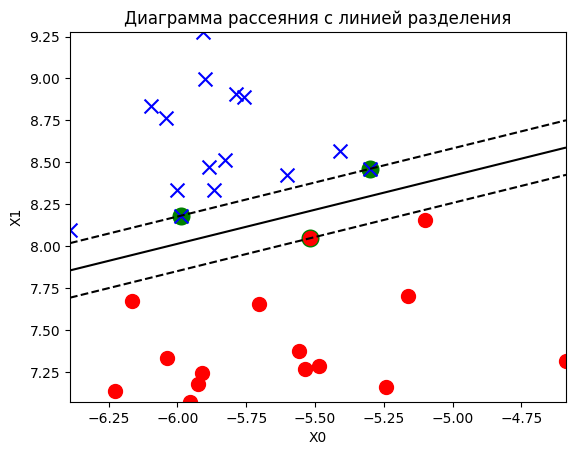

In [14]:
X0 = np.linspace(X[:, 0].min(), X[:, 0].max(), X.shape[0])
X1 = np.linspace(X[:, 1].min(), X[:, 1].max(), X.shape[0])

X0_grid, X1_grid = np.meshgrid(X0, X1)
Z = svm_linear.intercept_[0] + svm_linear.coef_[0][0] * X0_grid +  svm_linear.coef_[0][1] * X1_grid
plt.contour(X0_grid, X1_grid, Z, colors='k', levels=[-1, 0, 1], linestyles=['--', '-', '--'])

plt.scatter(svm_linear.support_vectors_[:, 0],svm_linear.support_vectors_[:, 1], linewidth=7, facecolors='green')

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния c линией разделения")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

In [15]:
y_pred =  svm_linear.predict(X)

In [16]:
metrics.accuracy_score(y, y_pred)

1.0

In [17]:
observation_new = [[-5.25, 7.5]]

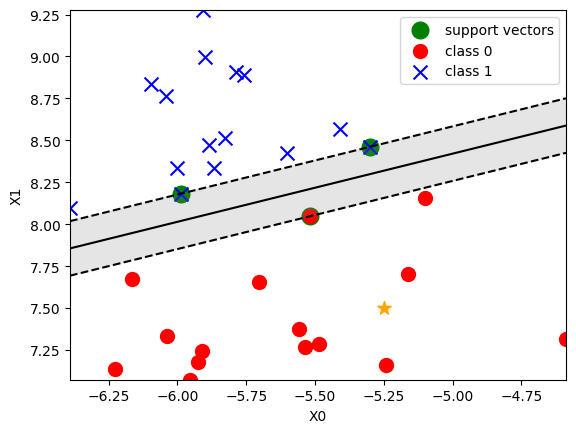

In [18]:
plt.scatter(observation_new[0][0], observation_new[0][1], marker='*', s=100, color='orange')
plot_decision_regions(X, y, svm_linear)

In [19]:
svm_linear.decision_function(observation_new)

array([-5.03131797])

In [20]:
svm_linear.predict(observation_new)

array([0])

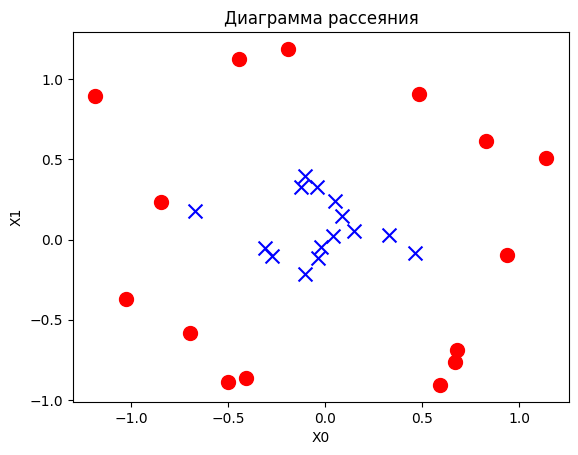

In [21]:
X, y = make_circles(n_samples=30, random_state=5, factor=.1, noise=.2)

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

In [22]:
svm_rbf = SVC(kernel='rbf', C=100).fit(X, y)

In [23]:
svm_rbf.n_support_
svm_rbf.support_
svm_rbf.support_vectors_

array([[ 0.9388294 , -0.09554628],
       [-0.84682371,  0.23287306],
       [-0.19166925,  1.18895776],
       [-0.69539045, -0.58523359],
       [ 0.68060508, -0.68615145],
       [ 0.48354792,  0.91063288],
       [-0.66975235,  0.17866445],
       [ 0.46427295, -0.08540628]])

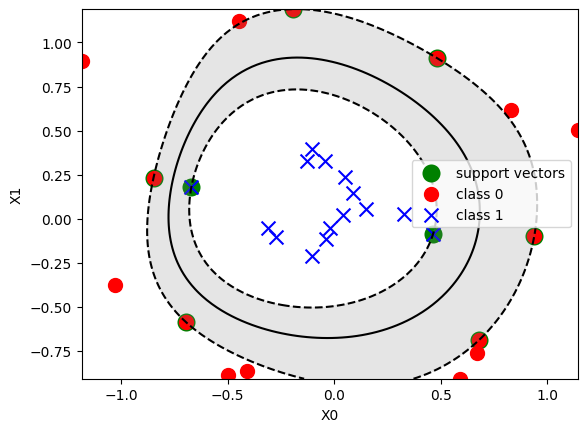

In [24]:
plot_decision_regions(X, y, svm_rbf)

In [25]:
metrics.accuracy_score(y, y_pred)
metrics.confusion_matrix(y, y_pred)

array([[7, 8],
       [8, 7]])

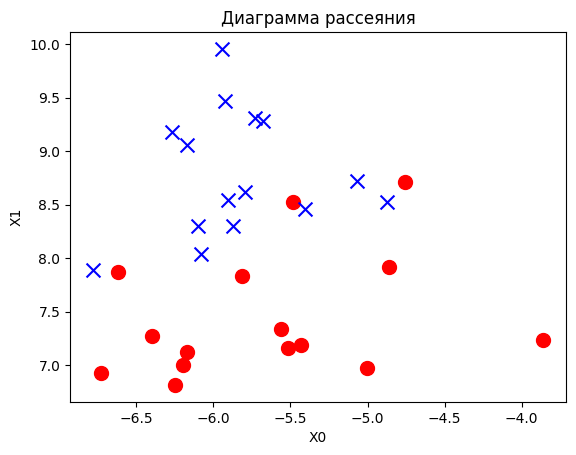

In [26]:
X, y = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.7)

plt.scatter(X[:, 0][y==0], X[:, 1][y==0], marker="o", c='r', s=100)
plt.scatter(X[:, 0][y==1], X[:, 1][y==1], marker="x", c='b', s=100)

plt.title("Диаграмма рассеяния")
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()

In [27]:
svm_poly = SVC(kernel='poly', degree=4, C=2).fit(X, y)

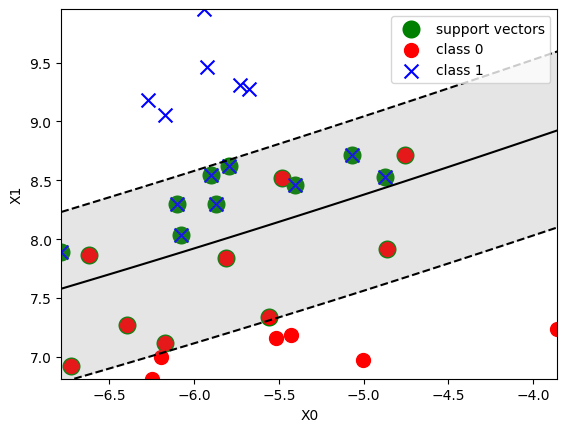

In [28]:
plot_decision_regions(X, y, svm_poly)

In [29]:
svm_poly.n_support_

array([9, 9], dtype=int32)

In [30]:
metrics.accuracy_score(y, y_pred)
metrics.confusion_matrix(y, y_pred)

array([[15,  0],
       [ 0, 15]])

In [31]:
observation_new = [[-5.25, 7.5]]
print("Решение функции:", svm_linear.decision_function(observation_new))
print("Предсказанный класс:", svm_linear.predict(observation_new))

Решение функции: [-5.03131797]
Предсказанный класс: [0]


# Задачи для самостоятельного решения

## Задание 1: Влияние параметра C на линейно разделимый датасет

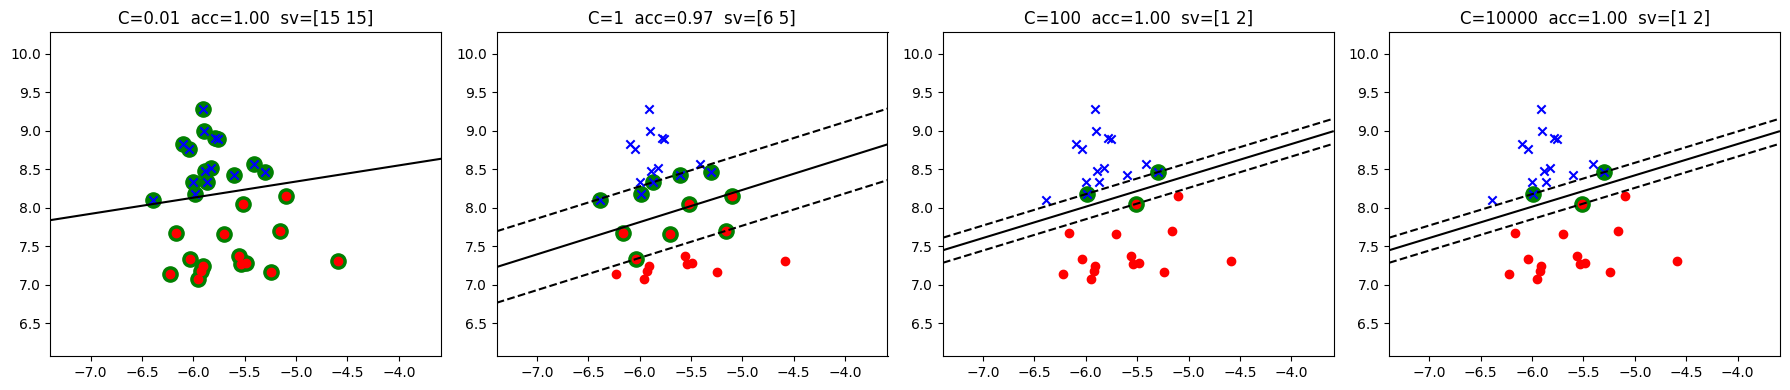

In [32]:
X1_sep, y1_sep = make_blobs(n_features=2, n_samples=30, centers=2, random_state=5, cluster_std=0.4)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, C in zip(axes, [0.01, 1, 100, 10000]):
    m = SVC(kernel='linear', C=C).fit(X1_sep, y1_sep)
    # рисуем вручную через decision_function
    X0g = np.linspace(X1_sep[:,0].min()-1, X1_sep[:,0].max()+1, 200)
    X1g = np.linspace(X1_sep[:,1].min()-1, X1_sep[:,1].max()+1, 200)
    xx, yy = np.meshgrid(X0g, X1g)
    Z = m.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contour(xx, yy, Z, colors='k', levels=[-1,0,1], linestyles=['--','-','--'])
    ax.scatter(m.support_vectors_[:,0], m.support_vectors_[:,1], s=120, facecolors='g')
    ax.scatter(X1_sep[:,0][y1_sep==0], X1_sep[:,1][y1_sep==0], c='r', marker='o')
    ax.scatter(X1_sep[:,0][y1_sep==1], X1_sep[:,1][y1_sep==1], c='b', marker='x')
    ax.set_title(f"C={C}  acc={m.score(X1_sep,y1_sep):.2f}  sv={m.n_support_}")

plt.tight_layout()
plt.show()
# Вывод: малый C → широкий зазор, больше опорных векторов, мягкая граница.
# Большой C → узкий зазор, меньше ошибок, риск переобучения.

## Задание 2: Точка предсказания по разные стороны границы и внутри зазора

In [33]:
m2 = SVC(kernel='linear', C=100).fit(X1_sep, y1_sep)

# Три контрольные точки: за классом 0, внутри зазора, за классом 1
test_points = [
    [-5.25, 7.5],   # явно класс 0
    [-5.25, 8.1],   # внутри зазора (между пунктирами)
    [-5.25, 8.9],   # явно класс 1
]

for pt in test_points:
    df = m2.decision_function([pt])[0]
    pred = m2.predict([pt])[0]
    zone = "внутри зазора" if abs(df) < 1 else "вне зазора"
    print(f"точка {pt}  df={df:.3f}  класс={pred}  [{zone}]")

точка [-5.25, 7.5]  df=-5.031  класс=0  [вне зазора]
точка [-5.25, 8.1]  df=-1.343  класс=0  [вне зазора]
точка [-5.25, 8.9]  df=3.574  класс=1  [вне зазора]


## Задание 3: Разные ядра на линейно неразделимом датасете (make_circles)

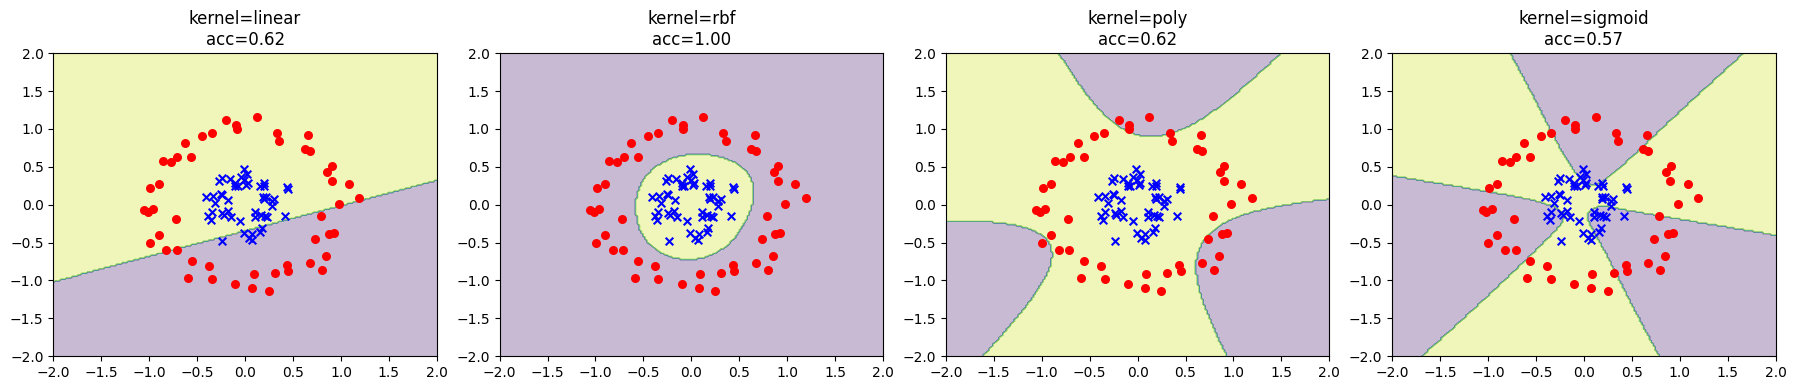

In [34]:
X_circ, y_circ = make_circles(n_samples=100, random_state=5, factor=0.3, noise=0.1)

kernels = ['linear', 'rbf', 'poly', 'sigmoid']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, kern in zip(axes, kernels):
    m = SVC(kernel=kern, C=10).fit(X_circ, y_circ)
    xx, yy = np.meshgrid(np.linspace(-2, 2, 200), np.linspace(-2, 2, 200))
    Z = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3)
    ax.scatter(X_circ[:,0][y_circ==0], X_circ[:,1][y_circ==0], c='r', marker='o', s=30)
    ax.scatter(X_circ[:,0][y_circ==1], X_circ[:,1][y_circ==1], c='b', marker='x', s=30)
    ax.set_title(f"kernel={kern}\nacc={m.score(X_circ,y_circ):.2f}")

plt.tight_layout()
plt.show()
# Вывод: rbf лучше всего разделяет кольцеобразные классы; linear неэффективен.

## Задание 4: Влияние C на пересекающиеся классы (make_blobs std=0.7)

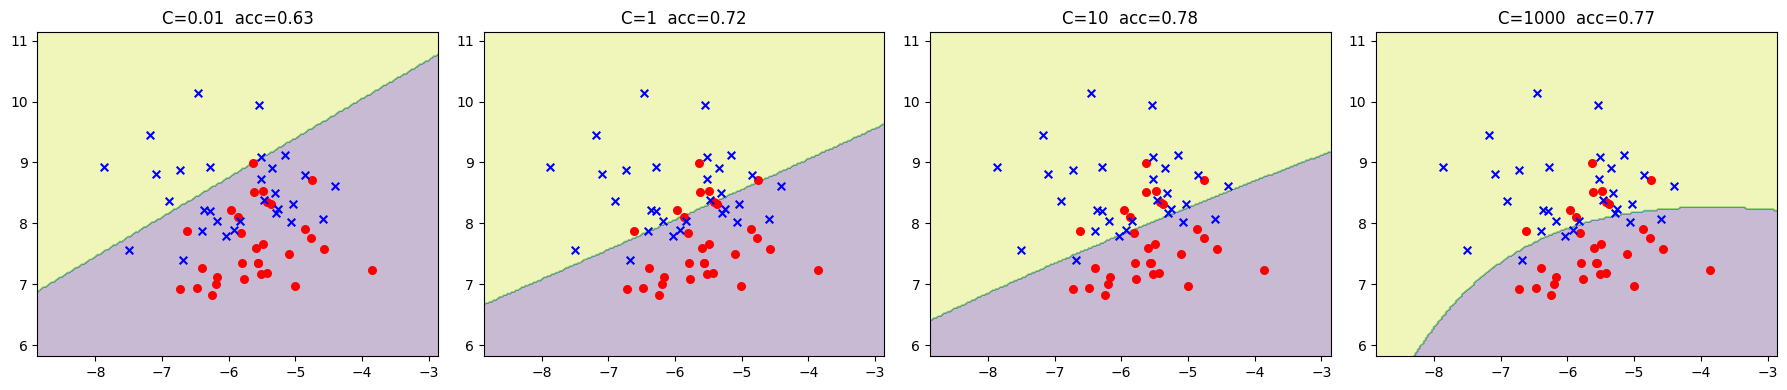

In [35]:
X_ov, y_ov = make_blobs(n_features=2, n_samples=60, centers=2, random_state=5, cluster_std=0.7)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, C in zip(axes, [0.01, 1, 10, 1000]):
    m = SVC(kernel='poly', degree=4, C=C).fit(X_ov, y_ov)
    xx, yy = np.meshgrid(np.linspace(X_ov[:,0].min()-1, X_ov[:,0].max()+1, 200),
                          np.linspace(X_ov[:,1].min()-1, X_ov[:,1].max()+1, 200))
    Z = m.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3)
    ax.scatter(X_ov[:,0][y_ov==0], X_ov[:,1][y_ov==0], c='r', marker='o', s=30)
    ax.scatter(X_ov[:,0][y_ov==1], X_ov[:,1][y_ov==1], c='b', marker='x', s=30)
    ax.set_title(f"C={C}  acc={m.score(X_ov,y_ov):.2f}")

plt.tight_layout()
plt.show()
# Вывод: при пересечении классов большой C пытается разделить все точки → сложная граница.

## Задание 5: LinearSVC на пересекающемся датасете

LinearSVC accuracy: 0.7667


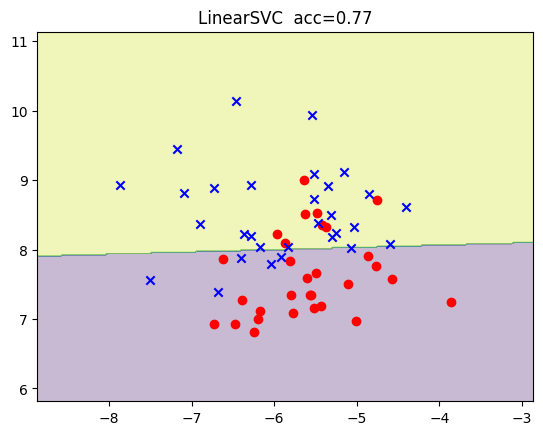

In [39]:
from sklearn.svm import LinearSVC

# LinearSVC — эффективная реализация линейного SVM без ядра
lin_svc = LinearSVC(C=1, max_iter=5000).fit(X_ov, y_ov)
print("LinearSVC accuracy:", round(lin_svc.score(X_ov, y_ov), 4))



xx, yy = np.meshgrid(np.linspace(X_ov[:,0].min()-1, X_ov[:,0].max()+1, 300),
                      np.linspace(X_ov[:,1].min()-1, X_ov[:,1].max()+1, 300))
Z = lin_svc.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_ov[:,0][y_ov==0], X_ov[:,1][y_ov==0], c='r', marker='o')
plt.scatter(X_ov[:,0][y_ov==1], X_ov[:,1][y_ov==1], c='b', marker='x')
plt.title(f"LinearSVC  acc={lin_svc.score(X_ov,y_ov):.2f}")
plt.show()

## Задание 6: 1000 точек, 5 признаков — подбор ядра и C

In [40]:
from sklearn.datasets import make_classification
import time

X6, y6 = make_classification(n_samples=1000, n_features=5, n_informative=4,
                              n_redundant=1, n_classes=2, random_state=0)

rows = []
for kern in ['linear', 'rbf', 'poly', 'sigmoid']:
    for C in [0.1, 1, 10, 100]:
        t0 = time.perf_counter()
        m = SVC(kernel=kern, C=C).fit(X6, y6)
        t = (time.perf_counter() - t0) * 1000
        rows.append({"kernel": kern, "C": C,
                     "acc": round(m.score(X6, y6), 4),
                     "time_ms": round(t, 1)})

import pandas as pd
df6 = pd.DataFrame(rows)
print(df6.sort_values("acc", ascending=False).head(8).to_string(index=False))

kernel     C   acc  time_ms
   rbf 100.0 0.942      9.8
   rbf  10.0 0.918      6.6
   rbf   1.0 0.891      6.2
   rbf   0.1 0.855      8.1
  poly 100.0 0.786    131.7
  poly  10.0 0.783     23.8
  poly   1.0 0.771      9.7
  poly   0.1 0.737      8.6


## Задание 7: SVM при разном числе точек — где время становится существенным?

n=   100  time=1.1 ms
n=   500  time=4.1 ms
n=  1000  time=5.3 ms
n=  3000  time=25.9 ms
n=  5000  time=37.3 ms
n= 10000  time=448.8 ms


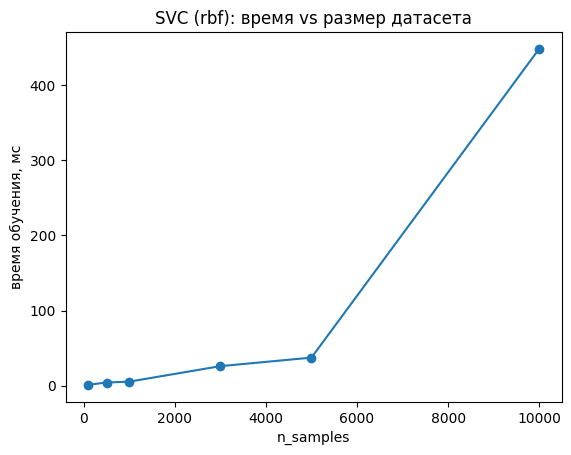

In [41]:
sizes = [100, 500, 1000, 3000, 5000, 10000]
times = []

for n in sizes:
    Xn, yn = make_classification(n_samples=n, n_features=5, random_state=0)
    t0 = time.perf_counter()
    SVC(kernel='rbf', C=1).fit(Xn, yn)
    times.append((time.perf_counter() - t0) * 1000)
    print(f"n={n:>6}  time={times[-1]:.1f} ms")

plt.plot(sizes, times, marker='o')
plt.xlabel("n_samples")
plt.ylabel("время обучения, мс")
plt.title("SVC (rbf): время vs размер датасета")
plt.show()
# Вывод: SVM имеет сложность O(n²)–O(n³) → при n>3000 время заметно растёт.

## Задание 8: Множественная классификация SVM (4 класса)

accuracy: 1.0


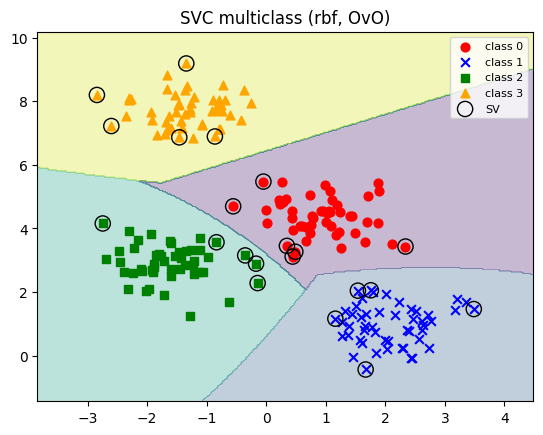

In [43]:
X8, y8 = make_blobs(n_samples=200, n_features=2, centers=4,
                    cluster_std=0.6, random_state=0)

# SVC автоматически решает OvO (один против одного) при n_classes > 2
m8 = SVC(kernel='rbf', C=10).fit(X8, y8)
print("accuracy:", round(m8.score(X8, y8),4))

xx, yy = np.meshgrid(np.linspace(X8[:,0].min()-1, X8[:,0].max()+1, 300),
                      np.linspace(X8[:,1].min()-1, X8[:,1].max()+1, 300))
Z8 = m8.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.contourf(xx, yy, Z8, alpha=0.3)
colors = ['r','b','g','orange']
markers = ['o','x','s','^']
for c in range(4):
    plt.scatter(X8[:,0][y8==c], X8[:,1][y8==c],
                c=colors[c], marker=markers[c], s=40, label=f"class {c}")
# Опорные векторы
plt.scatter(m8.support_vectors_[:,0], m8.support_vectors_[:,1],
            s=120, facecolors='none', edgecolors='k', label='SV')
plt.legend(fontsize=8)
plt.title("SVC multiclass (rbf, OvO)")
plt.show()

## Задание 9: SVM на готовом датасете sklearn (Breast Cancer)

In [44]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

bc = load_breast_cancer()
X9 = StandardScaler().fit_transform(bc.data)
y9 = bc.target

m9 = SVC(kernel='rbf', C=10).fit(X9, y9)
print(classification_report(y9, m9.predict(X9), target_names=bc.target_names))

              precision    recall  f1-score   support

   malignant       1.00      0.98      0.99       212
      benign       0.99      1.00      0.99       357

    accuracy                           0.99       569
   macro avg       0.99      0.99      0.99       569
weighted avg       0.99      0.99      0.99       569



## Задание 10: SVR — метод опорных векторов для регрессии

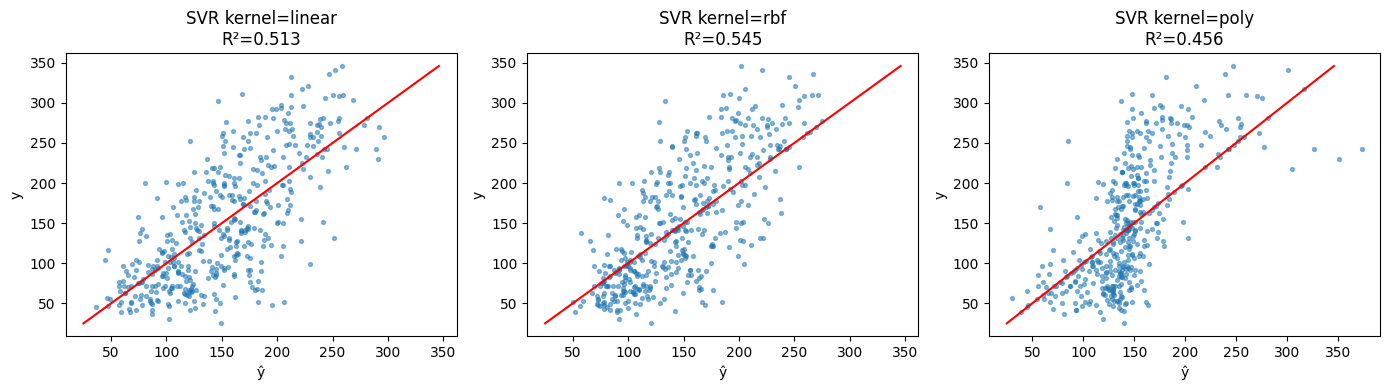

In [45]:
from sklearn.svm import SVR
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score

diab = load_diabetes()
X10 = StandardScaler().fit_transform(diab.data)
y10 = diab.target

# Сравниваем ядра SVR
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, kern in zip(axes, ['linear', 'rbf', 'poly']):
    m = SVR(kernel=kern, C=10).fit(X10, y10)
    yp = m.predict(X10)
    r2 = r2_score(y10, yp)
    ax.scatter(yp, y10, s=8, alpha=0.5)
    ax.plot([y10.min(), y10.max()], [y10.min(), y10.max()], 'r')
    ax.set_title(f"SVR kernel={kern}\nR²={r2:.3f}")
    ax.set_xlabel("ŷ"); ax.set_ylabel("y")

plt.tight_layout()
plt.show()